<a href="https://colab.research.google.com/github/nbasaranakgul/Experimentation/blob/main/NBADRAFT__Week13_Mini_Project_Build_a_Sequence_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## L7 — Mini-Project: Build a Sequence Analyzer (20 min)

### Your task

Bring together everything from L1–L6 to build a **complete sequence analysis tool**.

The tool will:
1. Accept a dictionary of gene sequences (already provided)
2. Analyze each sequence for key properties
3. Handle errors gracefully if any sequence is malformed
4. Output a formatted report table
5. Identify the most and least GC-rich genes

**Work in pairs.** The instructor will circulate and help.  
Complete as many steps as you can in 15 minutes.  
The bonus step at the end is a stretch goal.

---

### Step-by-step guide

Each `# STEP N:` comment tells you what to write. Fill in the blanks.

In [11]:
# ── Mini-project setup (already done for you — just run this) ────────────────

# A dictionary of gene name → DNA sequence fragment
gene_sequences = {
    "TP53":  "ATGGAGGAGCCGCAGTCAGATCCTAGCAGAGCGGGCCCTGGAGGGACAGGCAGCC",
    "EGFR":  "ATGCGACCCTCCGGGACGGCCGGGGCAGCGCTCCTGGCGCTGCTGGCTGCGCTC",
    "KRAS":  "ATGACTGAATATAAACTTGTGGTAGTTGGAGCTGATGGCGTAGGCAAGAGTGCCT",
    "MYC":   "ATGCCCCTCAACGTTAGCTTCACCAACAGGAACTATGACCTCGACTACGACTCGG",
    "PTEN":  "ATGACAGCCATCATCAAAGAGATCGTTAGCAGAAACAAAAGGAGATATCAAGGTG",
    "BRCA1": "ATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTATGC",
    "VHL":   "ATGCCCCGGAGTCCGGAGCGCGGCGGCGTCCCCCGGCCGTTGGAACAGCCGCTG",
    "bad":   "",                              # empty sequence — should be handled
    "messy": "ATGCGATCGG NNN ATCGG atcgg",   # lowercase + spaces + N's
}

print(f"Loaded {len(gene_sequences)} sequences")
print("Gene names:", list(gene_sequences.keys()))

Loaded 9 sequences
Gene names: ['TP53', 'EGFR', 'KRAS', 'MYC', 'PTEN', 'BRCA1', 'VHL', 'bad', 'messy']


In [12]:
# ── Mini-project: Step 1 — Clean sequences ────────────────────────────────────

def clean_sequence(raw_seq):
    """
    Clean a raw DNA sequence string:
    - Convert to uppercase
    - Remove spaces
    - Remove any non-ATGC characters (like N)
    Returns: cleaned string (may be empty if nothing valid remains)
    """
    # STEP 1a: Convert to uppercase
    seq = raw_seq.upper()

    # STEP 1b: Remove spaces
    # YOUR CODE HERE — use .replace(" ", "")
    seq = seq.replace(" ", "")

    # STEP 1c: Keep only valid nucleotides using a list comprehension
    # Hint: [char for char in seq if char in "ATGC"]
    # Then join back into a string
    valid_chars = [char for char in seq if char in "ATGC"]
    seq = "".join(valid_chars)

    return seq


# Test clean_sequence on a few examples
test_cases = [
    "ATGCGATCGG NNN ATCGG atcgg",   # messy
    "ATGGAGGAG",                     # already clean
    "",                              # empty
    "nnn nnn nnn",                   # all non-ATGC
]

print("Cleaning test:")
for raw in test_cases:
    cleaned = clean_sequence(raw)
    print(f"  Input:  {raw!r}")
    print(f"  Output: {cleaned!r}")
    print()

Cleaning test:
  Input:  'ATGCGATCGG NNN ATCGG atcgg'
  Output: 'ATGCGATCGGATCGGATCGG'

  Input:  'ATGGAGGAG'
  Output: 'ATGGAGGAG'

  Input:  ''
  Output: ''

  Input:  'nnn nnn nnn'
  Output: ''



In [19]:
# ── Mini-project: Step 2 — Analyze one sequence ──────────────────────────────

def analyze_sequence(gene_name, raw_seq):
    """
    Analyze a single DNA sequence.
    Returns a dictionary with all computed properties,
    or None if the sequence is unusable.
    """
    # STEP 2a: Clean the sequence first
    seq = clean_sequence(raw_seq)

    # STEP 2b: Handle empty sequence — return None
    # YOUR CODE HERE
    if len(seq) == 0:
        print(f" {gene_name}: empty after cleaning — skipping")
        return None

    # STEP 2c: Compute properties (fill in the blanks)
    length   = len(seq)

    # YOUR CODE HERE — count each nucleotide using .count()
    a_count  = seq.count('A')
    t_count  = seq.count('T')
    g_count  = seq.count('G')
    c_count  = seq.count('C')

    # YOUR CODE HERE — calculate GC content
    gc_pct   = round((g_count + c_count) / length * 100, 1)

    # Does it start with ATG (start codon)?
    has_start = seq.startswith("ATG")

    # STEP 2d: Return a dictionary with all results
    return {
        "gene":      gene_name,
        "length":    length,
        "gc_pct":    gc_pct,
        "a_pct":     round(a_count / length * 100, 1),
        "t_pct":     round(t_count / length * 100, 1),
        "g_pct":     round(g_count / length * 100, 1),
        "c_pct":     round(c_count / length * 100, 1),
        "has_start": has_start,
    }


# Test on one sequence
result = analyze_sequence("TP53", gene_sequences["TP53"])
print("Analysis of TP53:")
for key, val in result.items():
    print(f"  {key:<12}: {val}")

Analysis of TP53:
  gene        : TP53
  length      : 55
  gc_pct      : 67.3
  a_pct       : 23.6
  t_pct       : 9.1
  g_pct       : 40.0
  c_pct       : 27.3
  has_start   : True


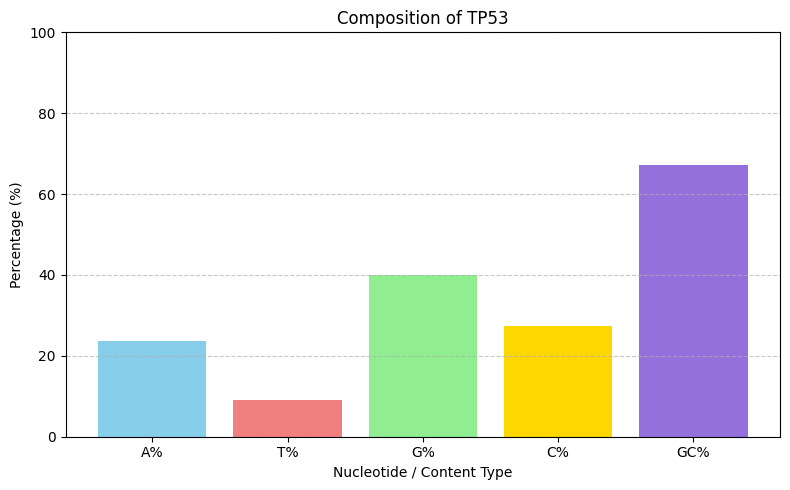

In [23]:
import matplotlib.pyplot as plt

# Find the TP53 gene data from the results list
tp53_data = next((r for r in results if r['gene'] == 'TP53'), None)

if tp53_data:
    gene_name = tp53_data['gene']
    percentages = [
        tp53_data['a_pct'],
        tp53_data['t_pct'],
        tp53_data['g_pct'],
        tp53_data['c_pct'],
        tp53_data['gc_pct']
    ]
    labels = ['A%', 'T%', 'G%', 'C%', 'GC%']

    plt.figure(figsize=(8, 5))
    plt.bar(labels, percentages, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple'])
    plt.xlabel('Nucleotide / Content Type')
    plt.ylabel('Percentage (%)')
    plt.title(f'Composition of {gene_name}')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("TP53 gene data not found in results.")

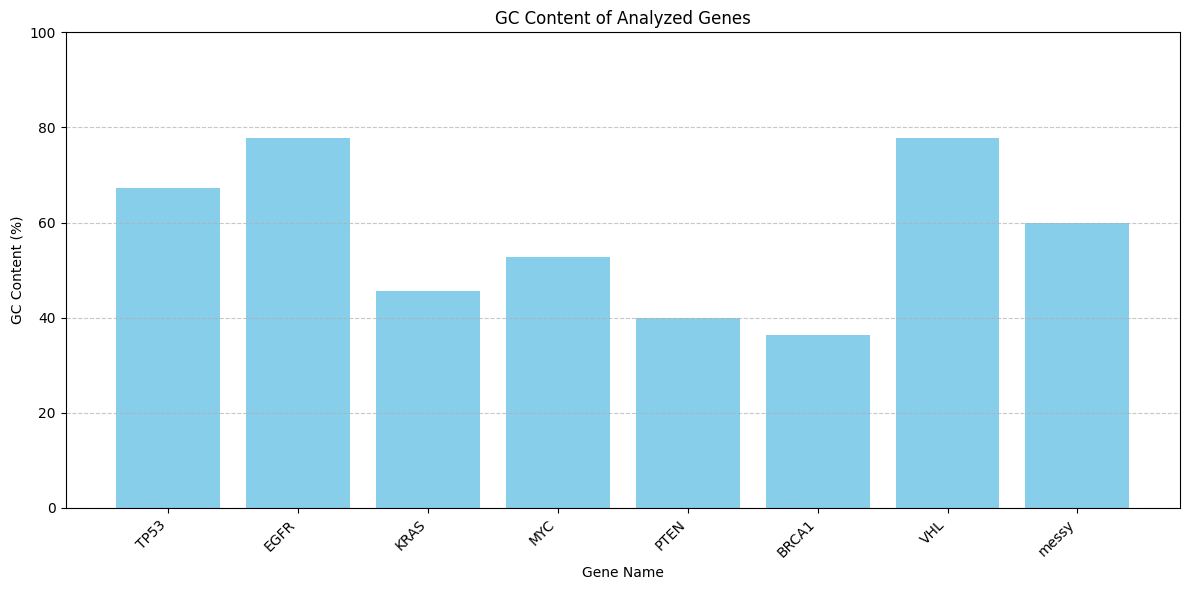

In [21]:
import matplotlib.pyplot as plt

# Extract gene names and GC percentages
gene_names = [r['gene'] for r in results]
gc_percentages = [r['gc_pct'] for r in results]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(gene_names, gc_percentages, color='skyblue')
plt.xlabel('Gene Name')
plt.ylabel('GC Content (%)')
plt.title('GC Content of Analyzed Genes')
plt.ylim(0, 100) # GC content is a percentage, so bounds are 0-100
plt.xticks(rotation=45, ha='right') # Rotate gene names for better readability if many genes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [15]:
# ── Mini-project: Step 3 — Analyze all sequences and print report ─────────────

# STEP 3a: Analyze all genes using a loop
# Store results in a list, skip any that return None
results = []

for gene_name, raw_seq in gene_sequences.items():
    result = analyze_sequence(gene_name, raw_seq)
    if result is not None:
        results.append(result)

print(f"Successfully analyzed {len(results)} sequences\n")

# STEP 3b: Print a formatted results table
print(f"{'Gene':<8} {'Length':>8} {'GC%':>7} {'A%':>6} {'T%':>6} {'G%':>6} {'C%':>6} {'Start?':>8}")
print("=" * 60)

for r in results:
    start_str = "✅ ATG" if r["has_start"] else "❌ no"
    print(f"{r['gene']:<8} {r['length']:>8} "
          f"{r['gc_pct']:>6.1f}% "
          f"{r['a_pct']:>5.1f}% "
          f"{r['t_pct']:>5.1f}% "
          f"{r['g_pct']:>5.1f}% "
          f"{r['c_pct']:>5.1f}%  "
          f"{start_str:>8}")

print("=" * 60)
print(f"{'Total sequences analyzed:':<35} {len(results)}")

  ⚠ bad: empty after cleaning — skipping
Successfully analyzed 8 sequences

Gene       Length     GC%     A%     T%     G%     C%   Start?
TP53           55   67.3%  23.6%   9.1%  40.0%  27.3%     ✅ ATG
EGFR           54   77.8%   7.4%  14.8%  38.9%  38.9%     ✅ ATG
KRAS           55   45.5%  27.3%  27.3%  32.7%  12.7%     ✅ ATG
MYC            55   52.7%  27.3%  20.0%  18.2%  34.5%     ✅ ATG
PTEN           55   40.0%  43.6%  16.4%  23.6%  16.4%     ✅ ATG
BRCA1          55   36.4%  29.1%  34.5%  20.0%  16.4%     ✅ ATG
VHL            54   77.8%  11.1%  11.1%  38.9%  38.9%     ✅ ATG
messy          20   60.0%  20.0%  20.0%  40.0%  20.0%     ✅ ATG
Total sequences analyzed:           8


In [16]:
# ── Mini-project: Step 4 — Find extremes and summarize ───────────────────────

# STEP 4a: Find the gene with the highest GC content
# Hint: use max() with key= to find the dict with the highest gc_pct
most_gc  = max(results, key=lambda r: r["gc_pct"])
least_gc = min(results, key=lambda r: r["gc_pct"])

print("GC Content Extremes:")
print(f"  Most GC-rich:  {most_gc['gene']:<8} {most_gc['gc_pct']:.1f}%")
print(f"  Least GC-rich: {least_gc['gene']:<8} {least_gc['gc_pct']:.1f}%")

# STEP 4b: List comprehension to get all genes that have a valid start codon
# YOUR CODE HERE
has_start_codon = [r["gene"] for r in results if r["has_start"]]
no_start_codon  = [r["gene"] for r in results if not r["has_start"]]

print(f"\nGenes with start codon (ATG): {has_start_codon}")
print(f"Genes without start codon:    {no_start_codon}")

# STEP 4c: Calculate mean GC content across all analyzed genes
# YOUR CODE HERE
mean_gc = sum(r["gc_pct"] for r in results) / len(results)
print(f"\nMean GC content across all genes: {mean_gc:.1f}%")

# STEP 4d: Sort and print genes by GC content (highest first)
sorted_by_gc = sorted(results, key=lambda r: r["gc_pct"], reverse=True)
print("\nGenes ranked by GC content:")
for i, r in enumerate(sorted_by_gc, 1):
    bar = "█" * int(r["gc_pct"] / 5)   # 5% per block
    print(f"  {i}. {r['gene']:<8} {r['gc_pct']:>5.1f}%  {bar}")

GC Content Extremes:
  Most GC-rich:  EGFR     77.8%
  Least GC-rich: BRCA1    36.4%

Genes with start codon (ATG): ['TP53', 'EGFR', 'KRAS', 'MYC', 'PTEN', 'BRCA1', 'VHL', 'messy']
Genes without start codon:    []

Mean GC content across all genes: 57.2%

Genes ranked by GC content:
  1. EGFR      77.8%  ███████████████
  2. VHL       77.8%  ███████████████
  3. TP53      67.3%  █████████████
  4. messy     60.0%  ████████████
  5. MYC       52.7%  ██████████
  6. KRAS      45.5%  █████████
  7. PTEN      40.0%  ████████
  8. BRCA1     36.4%  ███████


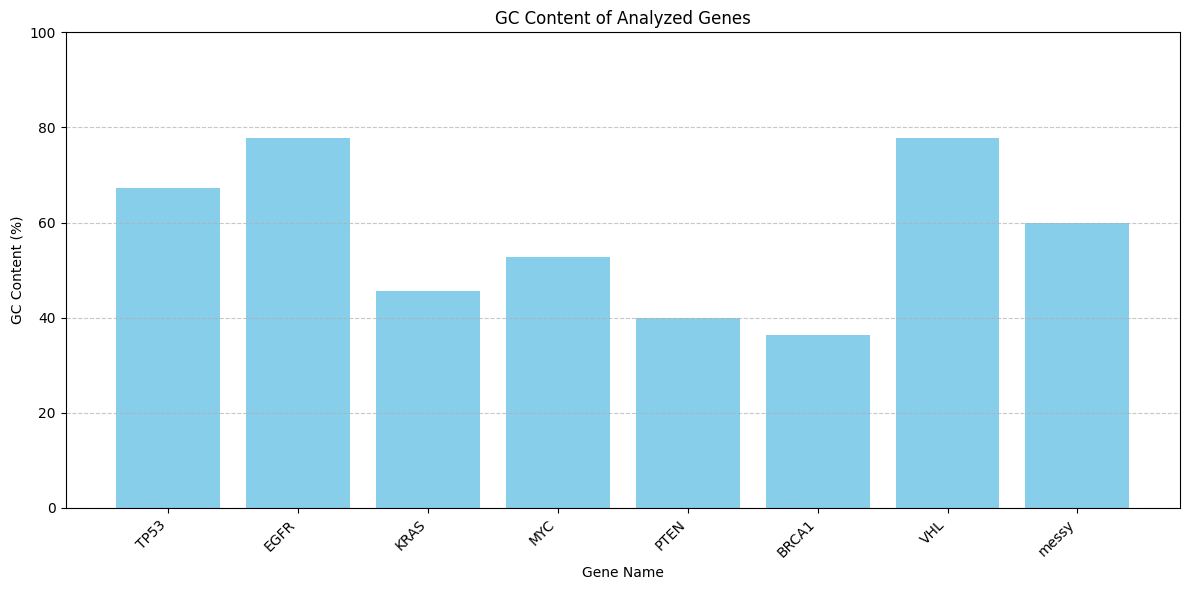

In [17]:
import matplotlib.pyplot as plt

# Extract gene names and GC percentages
gene_names = [r['gene'] for r in results]
gc_percentages = [r['gc_pct'] for r in results]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(gene_names, gc_percentages, color='skyblue')
plt.xlabel('Gene Name')
plt.ylabel('GC Content (%)')
plt.title('GC Content of Analyzed Genes')
plt.ylim(0, 100) # GC content is a percentage, so bounds are 0-100
plt.xticks(rotation=45, ha='right') # Rotate gene names for better readability if many genes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### ⭐ BONUS STEP — If you finish early

Extend the mini-project with one more function.

In [18]:
# ── BONUS: Write a function that generates a FASTA-format output ─────────────
# FASTA format:
# >gene_name GC=XX.X% length=NNN bp
# SEQUENCE_HERE

def to_fasta(gene_name, sequence, gc_pct, length):
    """Format a sequence as a FASTA record."""
    # BONUS CODE HERE
    # Line 1: header starting with > containing gene_name, gc_pct, length
    header   = f">{gene_name} GC={gc_pct:.1f}% length={length}bp"
    # Line 2: the sequence itself, broken into 60-character lines
    # Hint: [sequence[i:i+60] for i in range(0, len(sequence), 60)]
    seq_lines = [sequence[i:i+60] for i in range(0, len(sequence), 60)]
    return header + "\n" + "\n".join(seq_lines)


# Generate FASTA output for all successfully analyzed genes
print("FASTA format output:")
print("-" * 50)

for r in results:
    # Get the cleaned sequence from gene_sequences
    seq = clean_sequence(gene_sequences[r["gene"]])
    fasta = to_fasta(r["gene"], seq, r["gc_pct"], r["length"])
    print(fasta)
    print()

FASTA format output:
--------------------------------------------------
>TP53 GC=67.3% length=55bp
ATGGAGGAGCCGCAGTCAGATCCTAGCAGAGCGGGCCCTGGAGGGACAGGCAGCC

>EGFR GC=77.8% length=54bp
ATGCGACCCTCCGGGACGGCCGGGGCAGCGCTCCTGGCGCTGCTGGCTGCGCTC

>KRAS GC=45.5% length=55bp
ATGACTGAATATAAACTTGTGGTAGTTGGAGCTGATGGCGTAGGCAAGAGTGCCT

>MYC GC=52.7% length=55bp
ATGCCCCTCAACGTTAGCTTCACCAACAGGAACTATGACCTCGACTACGACTCGG

>PTEN GC=40.0% length=55bp
ATGACAGCCATCATCAAAGAGATCGTTAGCAGAAACAAAAGGAGATATCAAGGTG

>BRCA1 GC=36.4% length=55bp
ATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTATGC

>VHL GC=77.8% length=54bp
ATGCCCCGGAGTCCGGAGCGCGGCGGCGTCCCCCGGCCGTTGGAACAGCCGCTG

>messy GC=60.0% length=20bp
ATGCGATCGGATCGGATCGG



---
##  Lab Complete — What You Built Today

### Skills practiced

| Section | Skill | Applied to |
|---------|-------|-----------|
| L1 | Type conversion | Parsing raw data from files |
| L2 | Dictionaries | Gene expression lookup, genetic code |
| L3 | `zip()` and `enumerate()` | Processing parallel gene data lists |
| L4 | List comprehensions | Filtering and transforming sequences |
| L5 | `try/except` | Handling missing/bad data gracefully |
| L6 | String formatting | Professional output tables |
| L7 | Mini-project | Complete sequence analysis pipeline |

### Key things to remember

```python
int("42")           # type conversion — always convert before math
d.get(key, default) # safe dictionary lookup — never crashes
zip(list1, list2)   # loop two lists at once — no index needed
enumerate(mylist)   # loop with position — i starts at 0
[x*2 for x in lst] # list comprehension — transform in one line
[x for x in lst if condition]  # filter with comprehension
try: ... except ErrorType: ... # handle errors without crashing
f"{value:.2f}"      # f-string with 2 decimal places
```

### How to submit

1. **Runtime → Run all** — make sure every cell runs without errors
2. **File → Download → Download .ipynb**
3. Upload to Canvas before leaving class

---

### Next session

We will apply these Python tools to real RNA-seq count data from NCBI,  
compute differential expression, and produce publication-quality figures —  
connecting everything you have learned in both R and Python.

*Hands-on Bioinformatics & Genomics · Old Dominion University*